In [1]:
import numpy as np
import networkx as nx

TODO: Explore symbolic ml/symbolic regression with Mathematica

### Data Generation

In [2]:
def isospectral_reduction(A, S_indices, lam):
    """
    Compute A[S,S] - A[S,Sbar] @ inv(A[Sbar,Sbar] - lam I) @ A[Sbar,S]
    A: (n,n) numpy array (symmetric adjacency)
    S_indices: list/array of kept vertex indices (0-based)
    lam: scalar (float)
    Returns: reduced matrix (len(S_indices) x len(S_indices))
    """
    n = A.shape[0]
    S = np.array(S_indices, dtype=int)
    Sbar = np.setdiff1d(np.arange(n), S)
    A_SS = A[np.ix_(S, S)]
    if Sbar.size == 0:
        return A_SS.copy()
    A_S_Sbar = A[np.ix_(S, Sbar)]
    A_Sbar_S = A[np.ix_(Sbar, S)]
    A_Sbar_Sbar = A[np.ix_(Sbar, Sbar)]
    M = A_Sbar_Sbar - lam * np.eye(len(Sbar))
    try:
        Minv = np.linalg.inv(M)
    except np.linalg.LinAlgError:
        Minv = np.linalg.pinv(M + 1e-8 * np.eye(M.shape[0]))
    return A_SS - A_S_Sbar @ Minv @ A_Sbar_S

def evaluate_reduction_multilambda(A, S_indices, lambdas):
    """Evaluate the reduced matrix at multiple lambda points and return a stacked array of shape (k, m, m)"""
    return np.stack([isospectral_reduction(A, S_indices, lam) for lam in lambdas], axis=0)

In [3]:
def generate_dataset_er(n_graphs=200, n=12, p=0.25, m_keep=5, lambdas=None, seed=123):
    rng = np.random.RandomState(seed)
    if lambdas is None:
        lambdas = np.linspace(-3.0, 3.0, 200)
    data = []
    for i in range(n_graphs):
        G = nx.erdos_renyi_graph(n, p, seed=rng.randint(0, 1000000))
        tries = 0
        while (not nx.is_connected(G)) and tries < 5:
            G = nx.erdos_renyi_graph(n, p, seed=rng.randint(0, 1000000))
            tries += 1
        A = nx.to_numpy_array(G, dtype=float)
        S = rng.choice(n, size=m_keep, replace=False)
        R_multi = evaluate_reduction_multilambda(A, S, lambdas)
        data.append({'A': A, 'S': np.sort(S), 'R': R_multi})
    return data, np.array(lambdas)


In [4]:
data, lambdas = generate_dataset_er(n_graphs=100, n=15, p=0.25, m_keep=5)
print("Dataset size:", len(data), "lambdas:", lambdas)
print("Original graph n:", data[0]['A'].shape[0], "Reduced m:", data[0]['R'].shape[1])

Dataset size: 100 lambdas: [-3.         -2.96984925 -2.93969849 -2.90954774 -2.87939698 -2.84924623
 -2.81909548 -2.78894472 -2.75879397 -2.72864322 -2.69849246 -2.66834171
 -2.63819095 -2.6080402  -2.57788945 -2.54773869 -2.51758794 -2.48743719
 -2.45728643 -2.42713568 -2.39698492 -2.36683417 -2.33668342 -2.30653266
 -2.27638191 -2.24623116 -2.2160804  -2.18592965 -2.15577889 -2.12562814
 -2.09547739 -2.06532663 -2.03517588 -2.00502513 -1.97487437 -1.94472362
 -1.91457286 -1.88442211 -1.85427136 -1.8241206  -1.79396985 -1.7638191
 -1.73366834 -1.70351759 -1.67336683 -1.64321608 -1.61306533 -1.58291457
 -1.55276382 -1.52261307 -1.49246231 -1.46231156 -1.4321608  -1.40201005
 -1.3718593  -1.34170854 -1.31155779 -1.28140704 -1.25125628 -1.22110553
 -1.19095477 -1.16080402 -1.13065327 -1.10050251 -1.07035176 -1.04020101
 -1.01005025 -0.9798995  -0.94974874 -0.91959799 -0.88944724 -0.85929648
 -0.82914573 -0.79899497 -0.76884422 -0.73869347 -0.70854271 -0.67839196
 -0.64824121 -0.61809045 

In [5]:
def R_multilambda_to_feature(R_multi):
    """Flatten the multi-lambda reduced matrix into a feature vector"""
    k, m, _ = R_multi.shape
    idx = np.triu_indices(m, k=0)
    feats = []
    for i in range(k):
        feats.append(R_multi[i][idx])
    return np.concatenate(feats)

def A_to_upper_triangle_vector(A):
    """Return upper triangle (k=1) of adjacency matrix as a vector"""
    iu = np.triu_indices(A.shape[0], k=1)
    return A[iu]

In [6]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print("PyTorch available")
except Exception as e:
    print("PyTorch not available; install it to train the baseline.")
    torch = None

def try_train_baseline(data, lambdas, epochs=10, batch_size=32, lr=1e-3, device='cpu'):
    if torch is None:
        return None
    k = len(lambdas)
    m = data[0]['R'].shape[1]
    n = data[0]['A'].shape[0]
    X = np.array([R_multilambda_to_feature(d['R']) for d in data])
    Y = np.array([A_to_upper_triangle_vector(d['A']) for d in data])
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=device)

    input_dim = X_t.shape[1]
    output_dim = Y_t.shape[1]

    class MLP(nn.Module):
        def __init__(self, in_dim, out_dim, hidden=512):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, hidden),
                nn.ReLU(),
                nn.Linear(hidden, out_dim)
            )
        def forward(self, x):
            return self.net(x)

    model = MLP(input_dim, output_dim).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    N = X.shape[0]
    idxs = np.arange(N)
    for epoch in range(1, epochs+1):
        np.random.shuffle(idxs)
        model.train()
        epoch_loss = 0.0
        for start in range(0, N, batch_size):
            batch_idx = idxs[start:start+batch_size]
            xb = X_t[batch_idx]
            yb = Y_t[batch_idx]
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()
            epoch_loss += float(loss.item()) * xb.shape[0]
        epoch_loss /= N
        print(f"Epoch {epoch}/{epochs} loss={epoch_loss:.4f}")
    return {'model': model.to('cpu'), 'lambdas': lambdas, 'm': m, 'n': n}

PyTorch available


In [7]:
def sample_and_show(model_pack, data, num_examples=3):
    if torch is None:
        print("PyTorch not available")
        return
    model = model_pack['model']
    lambdas = model_pack['lambdas']
    m = model_pack['m']
    n = model_pack['n']
    N = len(data)
    for i in range(num_examples):
        idx = np.random.randint(0, N)
        d = data[idx]
        X = torch.tensor(R_multilambda_to_feature(d['R']), dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            logits = model(X).squeeze(0).numpy()
            probs = 1.0 / (1.0 + np.exp(-logits))
        A_hat = np.zeros((n, n))
        iu = np.triu_indices(n, k=1)
        A_hat[iu] = (probs > 0.5).astype(float)
        A_hat = A_hat + A_hat.T
        R_hat_multi = evaluate_reduction_multilambda(A_hat, d['S'], lambdas)
        err = np.sqrt(np.sum((R_hat_multi - d['R'])**2))
        print(f"Example {i}: reduction error (Frobenius over lambdas) = {err:.4g}")
        print("True edges:", int(np.sum(d['A'])/2), "Pred edges:", int(np.sum(A_hat)/2))
        print("First 6x6 block of predicted adjacency:")
        print(A_hat[:6,:6])
        print("-"*40)

In [8]:
data, lambdas = generate_dataset_er(n_graphs=800, n=10, p=0.25, m_keep=1)
model_pack = try_train_baseline(data, lambdas, epochs=20, batch_size=64, lr=1e-3)
if model_pack is not None:
    sample_and_show(model_pack, data, num_examples=5)

Epoch 1/20 loss=223.5966
Epoch 2/20 loss=17.4169
Epoch 3/20 loss=2.7874
Epoch 4/20 loss=2.3918
Epoch 5/20 loss=3.0264
Epoch 6/20 loss=12.1448
Epoch 7/20 loss=6.1460
Epoch 8/20 loss=2.3966
Epoch 9/20 loss=2.4651
Epoch 10/20 loss=9.2753
Epoch 11/20 loss=1.7797
Epoch 12/20 loss=1.6542
Epoch 13/20 loss=1.2688
Epoch 14/20 loss=0.9275
Epoch 15/20 loss=4.4705
Epoch 16/20 loss=4.9449
Epoch 17/20 loss=16.5168
Epoch 18/20 loss=1.2460
Epoch 19/20 loss=2.0882
Epoch 20/20 loss=0.6696
Example 0: reduction error (Frobenius over lambdas) = 2.332e+04
True edges: 16 Pred edges: 12
First 6x6 block of predicted adjacency:
[[0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 1.]
 [0. 1. 0. 1. 0. 1.]
 [0. 0. 1. 1. 1. 0.]]
----------------------------------------
Example 1: reduction error (Frobenius over lambdas) = 477.9
True edges: 12 Pred edges: 13
First 6x6 block of predicted adjacency:
[[0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 

In [9]:
import matplotlib.pyplot as plt

def visualize_graphs_side_by_side(true_A, pred_A, node_labels=None, title_true="True Graph", title_pred="Predicted Graph"):
    """
    Draw two graphs side by side from adjacency matrices true_A and pred_A
    """
    n = true_A.shape[0]
    G_true = nx.from_numpy_array(true_A)
    G_pred = nx.from_numpy_array(pred_A)
    
    # Layout (consistent for both)
    pos = nx.spring_layout(G_true, seed=42)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    nx.draw_networkx(G_true, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.title(title_true)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    nx.draw_networkx(G_pred, pos=pos, with_labels=True, node_color='lightgreen', edge_color='gray')
    plt.title(title_pred)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def sample_and_visualize(model_pack, data, num_examples=1, threshold=0.5):
    """
    Pick random examples, predict adjacency, compute predicted reduction error,
    and visualize the graphs.
    """
    if torch is None:
        print("PyTorch not available")
        return
    model = model_pack['model']
    lambdas = model_pack['lambdas']
    m = model_pack['m']
    n = model_pack['n']
    N = len(data)
    for i in range(num_examples):
        idx = np.random.randint(0, N)
        d = data[idx]
        X = torch.tensor(R_multilambda_to_feature(d['R']), dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            logits = model(X).squeeze(0).numpy()
            probs = 1.0 / (1.0 + np.exp(-logits))
        A_hat = np.zeros((n, n))
        iu = np.triu_indices(n, k=1)
        A_hat[iu] = (probs > threshold).astype(float)
        A_hat = A_hat + A_hat.T
        R_hat_multi = evaluate_reduction_multilambda(A_hat, d['S'], lambdas)
        err = np.sqrt(np.sum((R_hat_multi - d['R'])**2))
        print(f"Example {i}: reduction error (Frobenius over lambdas) = {err:.4g}")
        print("True edges:", int(np.sum(d['A'])/2), "Pred edges:", int(np.sum(A_hat)/2))
        
        visualize_graphs_side_by_side(d['A'], A_hat, title_true="True Graph", title_pred=f"Predicted Graph (err={err:.2f})")

Example 0: reduction error (Frobenius over lambdas) = 99.6
True edges: 14 Pred edges: 4


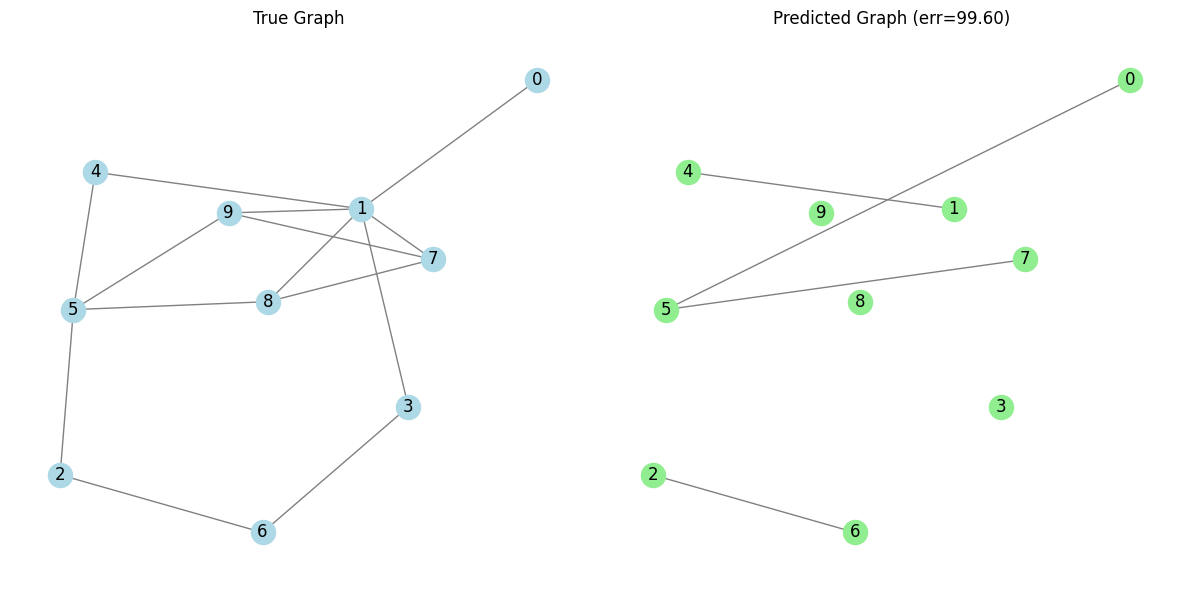

Example 1: reduction error (Frobenius over lambdas) = 272.3
True edges: 14 Pred edges: 4


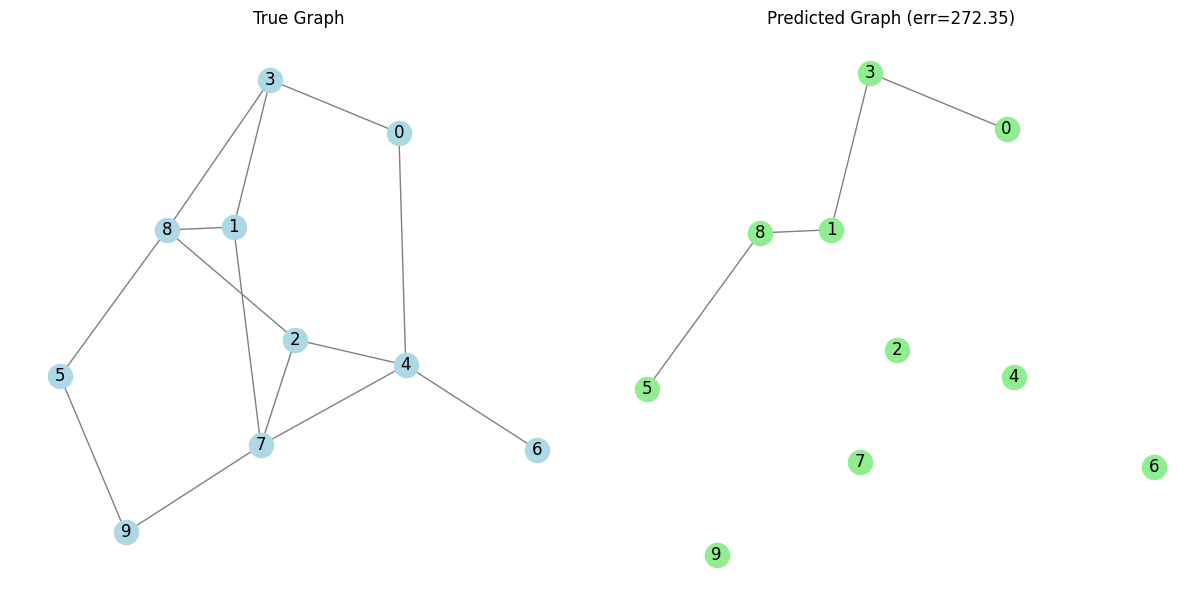

Example 2: reduction error (Frobenius over lambdas) = 287.1
True edges: 10 Pred edges: 8


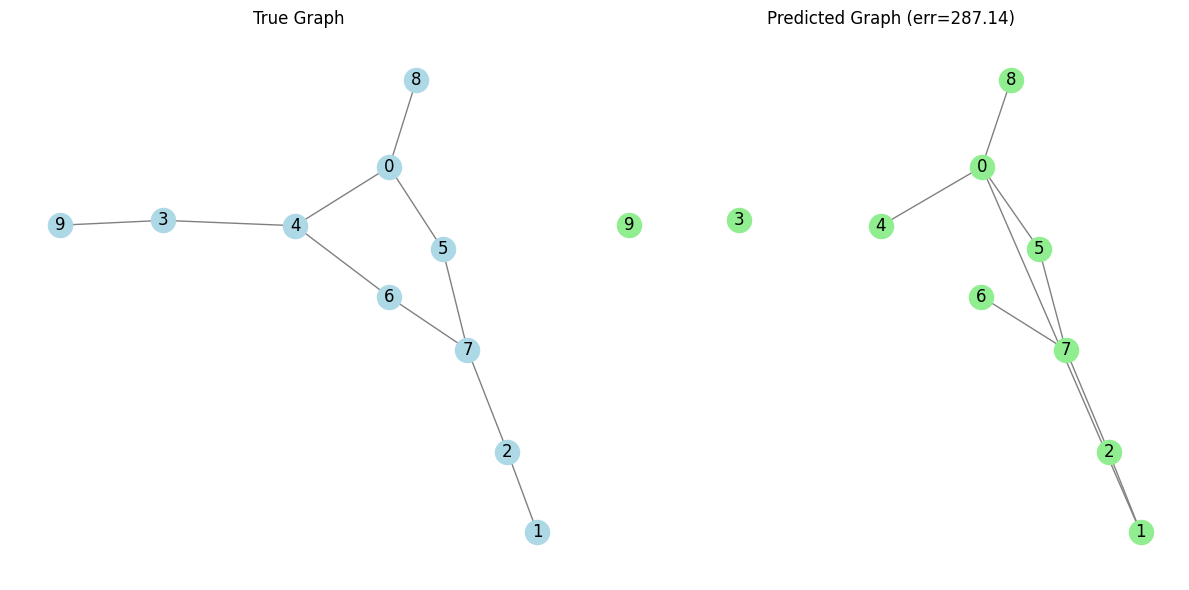

In [10]:
if model_pack is not None:
    sample_and_visualize(model_pack, data, num_examples=3)

In [11]:
# Cell 9: Visualize isospectral reductions of true vs. predicted graphs
def plot_isospectral_reductions(true_A, pred_A, S_indices, lambdas, mode='lines'):
    """
    Compare isospectral reductions of true and predicted graphs across λ values.
    mode: 'lines' (plot entries vs λ) or 'heatmap' (show |R| as color)
    """
    # Compute reductions
    R_true = evaluate_reduction_multilambda(true_A, S_indices, lambdas)
    R_pred = evaluate_reduction_multilambda(pred_A, S_indices, lambdas)
    k, m, _ = R_true.shape

    if mode == 'lines':
        plt.figure(figsize=(10, 6))
        for i in range(m):
            for j in range(i, m):
                plt.plot(lambdas, R_true[:, i, j], 'k-', alpha=0.6, label='True' if (i,j)==(0,0) else "")
                plt.plot(lambdas, R_pred[:, i, j], 'r--', alpha=0.6, label='Pred' if (i,j)==(0,0) else "")
        plt.xlabel("λ")
        plt.ylabel("Matrix entry value")
        plt.title("Isospectral Reductions (True vs Predicted)")
        plt.legend()
        plt.grid(True)
        plt.show()

    elif mode == 'heatmap':
        fig, axes = plt.subplots(2, k, figsize=(2*k, 5), sharex=True, sharey=True)
        for i, lam in enumerate(lambdas):
            im1 = axes[0, i].imshow(np.real(R_true[i]), cmap='viridis', vmin=-1, vmax=1)
            axes[0, i].set_title(f"True λ={lam:.2f}")
            axes[0, i].axis('off')
            im2 = axes[1, i].imshow(np.real(R_pred[i]), cmap='viridis', vmin=-1, vmax=1)
            axes[1, i].set_title(f"Pred λ={lam:.2f}")
            axes[1, i].axis('off')
        plt.suptitle("Isospectral Reduction Heatmaps (Top=True, Bottom=Predicted)")
        plt.colorbar(im1, ax=axes, orientation='vertical', fraction=0.02)
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("mode must be 'lines' or 'heatmap'")

In [12]:
# Cell 10: Run reduction comparison on one sample
def sample_and_compare_reductions(model_pack, data, sample_idx=None, mode='lines', threshold=0.5):
    if torch is None:
        print("PyTorch not available")
        return
    model = model_pack['model']
    lambdas = model_pack['lambdas']
    m = model_pack['m']
    n = model_pack['n']
    N = len(data)
    if sample_idx is None:
        sample_idx = np.random.randint(0, N)
    d = data[sample_idx]

    # Predict adjacency
    X = torch.tensor(R_multilambda_to_feature(d['R']), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        logits = model(X).squeeze(0).numpy()
        probs = 1.0 / (1.0 + np.exp(-logits))
    A_hat = np.zeros((n, n))
    iu = np.triu_indices(n, k=1)
    A_hat[iu] = (probs > threshold).astype(float)
    A_hat = A_hat + A_hat.T

    # Compute error
    R_hat_multi = evaluate_reduction_multilambda(A_hat, d['S'], lambdas)
    err = np.sqrt(np.sum((R_hat_multi - d['R'])**2))
    print(f"Sample {sample_idx}: reduction Frobenius error = {err:.4g}")

    # Plot reductions
    plot_isospectral_reductions(d['A'], A_hat, d['S'], lambdas, mode=mode)

Sample 417: reduction Frobenius error = 97.6


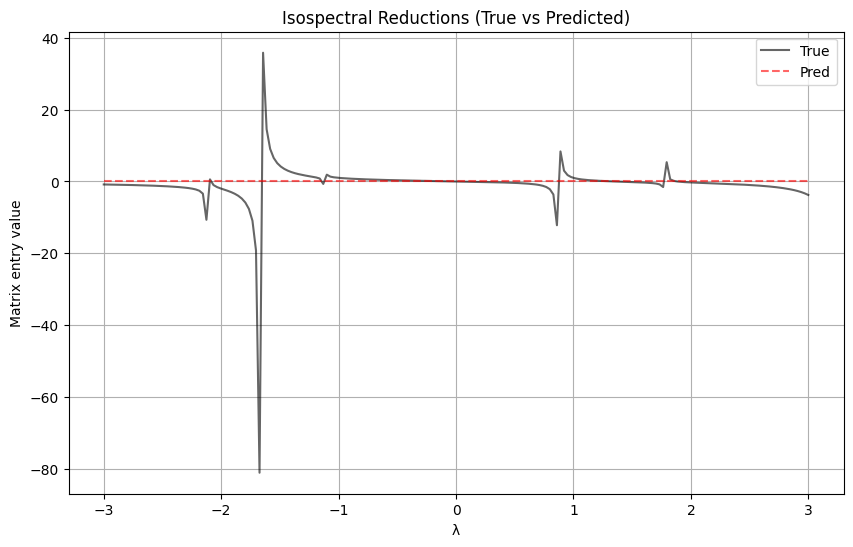

In [13]:
# Cell 11: Visualize isospectral reduction comparison for one example
if model_pack is not None:
    sample_and_compare_reductions(model_pack, data, mode='lines')

### Symbolic unfolding baseline (exact rational verification)

This section adds an exact symbolic verifier for isospectral reductions using SymPy.

Goals:
- Compare reductions as rational functions of λ exactly (not only on sampled grids)
- Evaluate candidate unfoldings by admissibility (exact match), validity, and diversity
- Provide a small search utility to generate families of valid unfoldings for a target reduction

In [24]:
import itertools
from collections import defaultdict

try:
    import sympy as sp
    print("SymPy available")
except Exception as e:
    sp = None
    print("SymPy not available. Install sympy to run symbolic verification.")

def _block_matrix(M, rows, cols):
    return sp.Matrix([[M[i, j] for j in cols] for i in rows])

def isospectral_reduction_symbolic(A, S_indices, lam=None):
    """Exact symbolic reduction A_SS - A_S,Sbar (A_Sbar,Sbar - lam I)^(-1) A_Sbar,S."""
    if sp is None:
        raise ImportError("sympy is required for symbolic reduction")
    if lam is None:
        lam = sp.symbols('lambda')
    A = sp.Matrix(A)
    n = A.shape[0]
    S = sorted(int(x) for x in S_indices)
    Sbar = [i for i in range(n) if i not in set(S)]
    A_SS = _block_matrix(A, S, S)
    if len(Sbar) == 0:
        return A_SS
    A_S_Sbar = _block_matrix(A, S, Sbar)
    A_Sbar_S = _block_matrix(A, Sbar, S)
    A_Sbar_Sbar = _block_matrix(A, Sbar, Sbar)
    M = A_Sbar_Sbar - lam * sp.eye(len(Sbar))
    R = A_SS - A_S_Sbar * M.inv() * A_Sbar_S
    return R.applyfunc(lambda expr: sp.cancel(sp.together(sp.simplify(expr))))

def reductions_equal_symbolic(R1, R2):
    if sp is None:
        raise ImportError("sympy is required for symbolic equality checking")
    if R1.shape != R2.shape:
        return False
    for i in range(R1.shape[0]):
        for j in range(R1.shape[1]):
            if sp.simplify(sp.together(R1[i, j] - R2[i, j])) != 0:
                return False
    return True

def reduction_entry_metadata(expr, lam=None):
    """Return degree/leading-coefficient metadata for one rational entry."""
    if sp is None:
        raise ImportError("sympy is required")
    if lam is None:
        lam = sp.symbols('lambda')
    rat = sp.cancel(sp.together(sp.simplify(expr)))
    num, den = sp.fraction(rat)
    num = sp.expand(num)
    den = sp.expand(den)
    poly_num = sp.Poly(num, lam)
    poly_den = sp.Poly(den, lam)
    deg_num = poly_num.degree()
    deg_den = poly_den.degree()
    lc_num = poly_num.LC()
    lc_den = poly_den.LC()
    lc_ratio = sp.simplify(lc_num / lc_den)
    return {
        'expr': rat,
        'numerator': num,
        'denominator': den,
        'deg_num': deg_num,
        'deg_den': deg_den,
        'degree_gap_den_minus_num': deg_den - deg_num,
        'leading_coeff_ratio': lc_ratio,
    }

def is_simple_connected_adjacency(A):
    A = np.array(A)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        return False
    if not np.allclose(A, A.T):
        return False
    if not np.allclose(np.diag(A), 0):
        return False
    if not np.all(np.isin(A, [0, 1])):
        return False
    G = nx.from_numpy_array(A.astype(int))
    return nx.is_connected(G)

def predict_adjacency_from_model(model_pack, datum, threshold=0.5):
    if torch is None:
        raise RuntimeError("PyTorch model is unavailable")
    model = model_pack['model']
    n = model_pack['n']

    # Convert one reduction sample into a single feature vector and predict edge logits.
    x = R_multilambda_to_feature(datum['R']).astype(np.float32)

    # Optional feature transform saved by a model pack (used by permutation-aware baseline).
    if 'feature_clip' in model_pack:
        x = np.clip(x, -float(model_pack['feature_clip']), float(model_pack['feature_clip']))
    if 'feature_mean' in model_pack and 'feature_std' in model_pack:
        x = (x - model_pack['feature_mean']) / model_pack['feature_std']

    X = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        logits = model(X).squeeze(0).numpy()
        probs = 1.0 / (1.0 + np.exp(-logits))

    # Interpret upper-triangle probabilities as Bernoulli edges, then symmetrize.
    A_hat = np.zeros((n, n), dtype=int)
    iu = np.triu_indices(n, k=1)
    A_hat[iu] = (probs > threshold).astype(int)
    A_hat = A_hat + A_hat.T
    return A_hat

def _canonical_graph_key(G):
    # Fast graph fingerprint (WL hash) used only as a diversity proxy, not a proof of non-isomorphism.
    return nx.weisfeiler_lehman_graph_hash(G)

def count_nonisomorphic_graphs(graphs):
    reps = []
    for G in graphs:
        is_new = True
        for H in reps:
            if nx.is_isomorphic(G, H):
                is_new = False
                break
        if is_new:
            reps.append(G)
    return len(reps)

SymPy available


In [28]:
import time

def evaluate_generator_symbolic(model_pack, data, num_samples=50, threshold=0.5, seed=0):
    """
    Evaluate generated unfoldings using exact symbolic reduction checks.
    Returns admissibility, validity, and diversity stats.
    """
    if sp is None:
        raise ImportError("sympy is required")
    if torch is None:
        raise RuntimeError("PyTorch model is unavailable")

    rng = np.random.RandomState(seed)
    lam = sp.symbols('lambda')

    valid_count = 0
    admissible_count = 0
    admissible_graphs = []
    admissible_by_key = defaultdict(int)

    for _ in range(num_samples):
        idx = int(rng.randint(0, len(data)))
        datum = data[idx]
        A_true = np.array(datum['A'], dtype=int)
        S = [int(x) for x in datum['S']]

        # Step 1: generate a candidate unfolding graph.
        A_hat = predict_adjacency_from_model(model_pack, datum, threshold=threshold)

        # Step 2: enforce structural constraints (simple, undirected, connected).
        is_valid = is_simple_connected_adjacency(A_hat)
        if is_valid:
            valid_count += 1
        else:
            continue

        # Step 3: exact symbolic admissibility check of reductions over lambda.
        R_true = isospectral_reduction_symbolic(A_true, S, lam=lam)
        R_hat = isospectral_reduction_symbolic(A_hat, S, lam=lam)
        if reductions_equal_symbolic(R_true, R_hat):
            admissible_count += 1
            G_hat = nx.from_numpy_array(A_hat.astype(int))
            admissible_graphs.append(G_hat)
            admissible_by_key[_canonical_graph_key(G_hat)] += 1

    # Rates over all generation attempts.
    validity_rate = valid_count / max(num_samples, 1)
    admissibility_rate = admissible_count / max(num_samples, 1)
    # Optional conditional view: among structurally valid graphs, how many are admissible.
    admissibility_given_valid_rate = admissible_count / max(valid_count, 1)

    unique_wl = len(admissible_by_key)
    unique_noniso = count_nonisomorphic_graphs(admissible_graphs) if admissible_graphs else 0

    return {
        'num_samples': num_samples,
        'valid_count': valid_count,
        'admissible_count': admissible_count,
        'validity_rate': validity_rate,
        'admissibility_rate': admissibility_rate,
        'admissibility_given_valid_rate': admissibility_given_valid_rate,
        'unique_wl_hashes_among_admissible': unique_wl,
        'unique_nonisomorphic_among_admissible': unique_noniso,
    }

def find_unfoldings_for_target_reduction(
    target_R,
    keep_size=1,
    n_max=7,
    max_checks=600,
    time_limit_sec=45,
    dedupe_subsets_per_graph=True,
    verbose=False,
):
    """
    Brute-force small-graph search over graph atlas to find unfoldings matching target_R exactly.
    Uses check/time caps to keep runtimes practical.
    """
    if sp is None:
        raise ImportError("sympy is required")
    lam = sp.symbols('lambda')
    matches = []
    checks = 0
    t0 = time.time()

    atlas = nx.graph_atlas_g()
    for G0 in atlas:
        n = G0.number_of_nodes()
        if n < keep_size + 1 or n > n_max:
            continue
        if not nx.is_connected(G0):
            continue
        if nx.number_of_selfloops(G0) > 0:
            continue

        G = nx.convert_node_labels_to_integers(G0)
        A = nx.to_numpy_array(G, dtype=int)

        for S in itertools.combinations(range(n), keep_size):
            checks += 1
            if checks > max_checks or (time.time() - t0) > time_limit_sec:
                if verbose:
                    print(f"Stopped early after {checks} checks and {time.time()-t0:.1f}s")
                reps = []
                for item in matches:
                    G_item = item['graph']
                    if not any(nx.is_isomorphic(G_item, rep['graph']) for rep in reps):
                        reps.append(item)
                return reps

            R = isospectral_reduction_symbolic(A, S, lam=lam)
            if reductions_equal_symbolic(R, target_R):
                matches.append({
                    'n': n,
                    'S': tuple(S),
                    'graph': G.copy(),
                    'A': A.copy(),
                })
                if dedupe_subsets_per_graph:
                    break

    reps = []
    for item in matches:
        G_item = item['graph']
        if not any(nx.is_isomorphic(G_item, rep['graph']) for rep in reps):
            reps.append(item)
    return reps

def summarize_symbolic_constraints_on_reduction(R, max_entries=6):
    """Quick look at degree gaps and leading coefficient ratios for a reduction matrix."""
    if sp is None:
        raise ImportError("sympy is required")
    lam = sp.symbols('lambda')
    m = R.shape[0]
    out = []
    counter = 0
    for i in range(m):
        for j in range(m):
            meta = reduction_entry_metadata(R[i, j], lam=lam)
            out.append(((i, j), meta['degree_gap_den_minus_num'], meta['leading_coeff_ratio']))
            counter += 1
            if counter >= max_entries:
                return out
    return out

In [16]:
# Demo 1: exact symbolic admissibility/diversity for the current neural generator
if model_pack is not None and sp is not None:
    metrics = evaluate_generator_symbolic(model_pack, data, num_samples=40, threshold=0.5, seed=7)
    print("Symbolic generator metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
else:
    print("Need a trained model_pack and sympy for this demo.")

/home/dallin/Documents/Classes/Graph_Theory/isospectral_pst/unfolding/unfolding_ml/.venv/lib/python3.12/site-packages/networkx/algorithms/graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributeschanged in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)
/tmp/ipykernel_6775/525800063.py:93: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Symbolic generator metrics:
  num_samples: 40
  valid_count: 12
  admissible_count: 2
  validity_rate: 0.3
  admissibility_rate: 0.05
  unique_wl_hashes_among_admissible: 2
  unique_nonisomorphic_among_admissible: 2


In [21]:
# Demo 2: tiny exact family search for a target reduction
if sp is not None:
    lam = sp.symbols('lambda')
    # Build target from a known simple graph example in this notebook style
    # (path on 3 vertices, reduced to middle vertex)
    G_demo = nx.path_graph(3)
    A_demo = nx.to_numpy_array(G_demo, dtype=int)
    target_R = isospectral_reduction_symbolic(A_demo, [1], lam=lam)
    print("Target reduction entry:", sp.simplify(target_R[0, 0]))

    families = find_unfoldings_for_target_reduction(
        target_R, keep_size=1, n_max=6, max_checks=300, time_limit_sec=20
    )
    print("Non-isomorphic matching unfoldings found:", len(families))
    for i, item in enumerate(families[:10]):
        print(f"  #{i+1}: n={item['n']} keep={item['S']} edges={item['graph'].number_of_edges()}")
else:
    print("SymPy not available.")

Target reduction entry: 2/lambda
Non-isomorphic matching unfoldings found: 1
  #1: n=3 keep=(0,) edges=2


### Permutation-aware baseline (permutation-minimized target loss)

This baseline keeps the same MLP architecture but changes training loss.

For each training sample, we compare the model prediction against several random vertex permutations of the target graph and use the **minimum BCE loss**. This makes training tolerant to label permutations and better aligned with unlabeled graph recovery.

In [ ]:
def _permute_adjacency(A, perm):
    return A[np.ix_(perm, perm)]

def _permuted_edge_targets_for_batch(A_batch, n, num_target_perms, rng):
    """Return tensor-like numpy array of shape (K, B, E) with permuted target edge vectors."""
    y_candidates = []
    K = max(int(num_target_perms), 1)
    for k in range(K):
        yk = []
        for A in A_batch:
            if k == 0:
                perm = np.arange(n)  # include identity target each step
            else:
                perm = rng.permutation(n)
            A_perm = _permute_adjacency(A, perm)
            yk.append(A_to_upper_triangle_vector(A_perm))
        y_candidates.append(np.array(yk, dtype=np.float32))
    return np.stack(y_candidates, axis=0)

def try_train_permutation_aware_baseline(
    data,
    lambdas,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    device='cpu',
    hidden=512,
    num_target_perms=4,
    seed=123,
    x_clip=10.0,
    verbose=True,
    eval_every=1,
    quick_symbolic_eval=False,
    symbolic_eval_samples=12,
):
    """
    Train an MLP using permutation-minimized target loss.

    For each sample in a batch, compare logits against multiple random permutations
    of the target adjacency and backprop through the minimum BCE loss.
    """
    if torch is None:
        return None
    rng = np.random.RandomState(seed)

    m = data[0]['R'].shape[1]
    n = data[0]['A'].shape[0]

    # Clipping for stability (unstable when numerical sample of the reduction is close to asymptotes)
    X_raw = np.array([R_multilambda_to_feature(d['R']) for d in data], dtype=np.float32)
    X_clipped = np.clip(X_raw, -x_clip, x_clip)
    feat_mean = X_clipped.mean(axis=0)
    feat_std = X_clipped.std(axis=0) + 1e-6
    X = (X_clipped - feat_mean) / feat_std

    A_list = [np.array(d['A'], dtype=int) for d in data]

    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    input_dim = X_t.shape[1]
    output_dim = len(A_to_upper_triangle_vector(A_list[0]))

    class PermAwareMLP(nn.Module):
        def __init__(self, in_dim, out_dim, hidden_dim=512):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, out_dim),
            )
        def forward(self, x):
            return self.net(x)

    model = PermAwareMLP(input_dim, output_dim, hidden_dim=hidden).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion_none = nn.BCEWithLogitsLoss(reduction='none')

    N = X.shape[0]
    idxs = np.arange(N)

    for epoch in range(1, epochs + 1):
        np.random.shuffle(idxs)
        model.train()
        epoch_loss = 0.0

        for start in range(0, N, batch_size):
            batch_idx = idxs[start:start + batch_size]
            xb = X_t[batch_idx]
            logits = model(xb)  # (B, E)

            # Build K permuted target vectors per sample: (K, B, E)
            A_batch = [A_list[i] for i in batch_idx]
            y_candidates_np = _permuted_edge_targets_for_batch(
                A_batch=A_batch,
                n=n,
                num_target_perms=num_target_perms,
                rng=rng,
            )
            y_candidates = torch.tensor(y_candidates_np, dtype=torch.float32, device=device)

            # Compute BCE for each candidate permutation and choose min per sample.
            logits_expanded = logits.unsqueeze(0).expand(y_candidates.shape[0], -1, -1)
            per_edge_loss = criterion_none(logits_expanded, y_candidates)  # (K, B, E)
            per_sample_loss = per_edge_loss.mean(dim=2)  # (K, B)
            min_per_sample = per_sample_loss.min(dim=0).values  # (B,)
            loss = min_per_sample.mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            epoch_loss += float(loss.item()) * xb.shape[0]

        epoch_loss /= N
        if verbose and (epoch % eval_every == 0):
            print(f"[perm-aware] Epoch {epoch}/{epochs} loss={epoch_loss:.4f}")

    model_pack = {
        'model': model.to('cpu'),
        'lambdas': lambdas,
        'm': m,
        'n': n,
        'permutation_aware': True,
        'num_target_perms': int(max(num_target_perms, 1)),
        'feature_clip': float(x_clip),
        'feature_mean': feat_mean.astype(np.float32),
        'feature_std': feat_std.astype(np.float32),
    }

    if quick_symbolic_eval and sp is not None:
        metrics = evaluate_generator_symbolic(
            model_pack=model_pack,
            data=data,
            num_samples=symbolic_eval_samples,
            threshold=0.5,
            seed=seed,
        )
        print("[perm-aware] quick symbolic metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v}")

    return model_pack

In [27]:
# Demo 3: train + evaluate permutation-aware baseline (small/quick setting)
perm_model_pack = None
if torch is not None:
    data_perm, lambdas_perm = generate_dataset_er(
        n_graphs=300, n=10, p=0.25, m_keep=1, seed=777
    )
    perm_model_pack = try_train_permutation_aware_baseline(
        data=data_perm,
        lambdas=lambdas_perm,
        epochs=6,
        batch_size=64,
        lr=1e-3,
        hidden=512,
        num_target_perms=4,
        seed=777,
        quick_symbolic_eval=False,
    )

    if sp is not None and perm_model_pack is not None:
        for thr in [0.35, 0.45, 0.50]:
            perm_metrics = evaluate_generator_symbolic(
                perm_model_pack, data_perm, num_samples=30, threshold=thr, seed=11
            )
            print(f"Permutation-aware symbolic metrics @ threshold={thr}:")
            for k, v in perm_metrics.items():
                print(f"  {k}: {v}")
else:
    print("PyTorch not available.")

[perm-aware] Epoch 1/6 loss=0.6496
[perm-aware] Epoch 2/6 loss=0.6024
[perm-aware] Epoch 3/6 loss=0.5927
[perm-aware] Epoch 4/6 loss=0.5894
[perm-aware] Epoch 5/6 loss=0.5819
[perm-aware] Epoch 6/6 loss=0.5800
Permutation-aware symbolic metrics @ threshold=0.35:
  num_samples: 30
  valid_count: 8
  admissible_count: 0
  validity_rate: 0.26666666666666666
  admissibility_rate: 0.0
  unique_wl_hashes_among_admissible: 0
  unique_nonisomorphic_among_admissible: 0
Permutation-aware symbolic metrics @ threshold=0.45:
  num_samples: 30
  valid_count: 0
  admissible_count: 0
  validity_rate: 0.0
  admissibility_rate: 0.0
  unique_wl_hashes_among_admissible: 0
  unique_nonisomorphic_among_admissible: 0
Permutation-aware symbolic metrics @ threshold=0.5:
  num_samples: 30
  valid_count: 0
  admissible_count: 0
  validity_rate: 0.0
  admissibility_rate: 0.0
  unique_wl_hashes_among_admissible: 0
  unique_nonisomorphic_among_admissible: 0


### Threshold calibration + longer-run preset

This section tunes the graph decoding threshold on a validation split using exact symbolic metrics, then reports test performance at the selected threshold.

In [29]:
def split_dataset(data, train_frac=0.7, val_frac=0.15, seed=123):
    rng = np.random.RandomState(seed)
    idx = np.arange(len(data))
    rng.shuffle(idx)

    n = len(data)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    train_data = [data[i] for i in train_idx]
    val_data = [data[i] for i in val_idx]
    test_data = [data[i] for i in test_idx]
    return train_data, val_data, test_data

def calibrate_threshold_symbolic(
    model_pack,
    val_data,
    thresholds=None,
    num_samples=40,
    seed=0,
    objective='admissibility_then_validity',
):
    """
    Evaluate candidate thresholds on val_data and pick the best one.
    objective options:
      - 'admissibility_then_validity'
      - 'validity_then_admissibility'
      - 'admissibility_given_valid'
    """
    if thresholds is None:
        thresholds = np.linspace(0.2, 0.6, 9)

    rows = []
    for thr in thresholds:
        metrics = evaluate_generator_symbolic(
            model_pack=model_pack,
            data=val_data,
            num_samples=num_samples,
            threshold=float(thr),
            seed=seed,
        )
        rows.append({'threshold': float(thr), **metrics})

    if objective == 'validity_then_admissibility':
        best = max(rows, key=lambda r: (r['validity_rate'], r['admissibility_rate']))
    elif objective == 'admissibility_given_valid':
        best = max(rows, key=lambda r: (r['admissibility_given_valid_rate'], r['validity_rate']))
    else:
        best = max(rows, key=lambda r: (r['admissibility_rate'], r['validity_rate']))

    return best['threshold'], rows

def train_permutation_aware_longer_preset(
    data,
    lambdas,
    seed=123,
    quick=False,
    quick_symbolic_eval=False,
):
    """A stronger preset than Demo 3; `quick=True` uses lighter settings."""
    if quick:
        return try_train_permutation_aware_baseline(
            data=data,
            lambdas=lambdas,
            epochs=10,
            batch_size=64,
            lr=8e-4,
            hidden=512,
            num_target_perms=6,
            seed=seed,
            x_clip=10.0,
            quick_symbolic_eval=quick_symbolic_eval,
            symbolic_eval_samples=20,
        )

    return try_train_permutation_aware_baseline(
        data=data,
        lambdas=lambdas,
        epochs=25,
        batch_size=64,
        lr=8e-4,
        hidden=512,
        num_target_perms=8,
        seed=seed,
        x_clip=10.0,
        quick_symbolic_eval=quick_symbolic_eval,
        symbolic_eval_samples=30,
    )

In [30]:
# Demo 4: train longer preset + calibrate threshold on validation split
if torch is not None and sp is not None:
    data_cal, lambdas_cal = generate_dataset_er(
        n_graphs=450, n=10, p=0.25, m_keep=1, seed=2026
    )
    train_data, val_data, test_data = split_dataset(data_cal, train_frac=0.7, val_frac=0.15, seed=2026)
    print(f"Split sizes: train={len(train_data)} val={len(val_data)} test={len(test_data)}")

    perm_model_pack_long = train_permutation_aware_longer_preset(
        data=train_data,
        lambdas=lambdas_cal,
        seed=2026,
        quick=True,
        quick_symbolic_eval=False,
    )

    best_thr, val_rows = calibrate_threshold_symbolic(
        perm_model_pack_long,
        val_data,
        thresholds=np.linspace(0.2, 0.6, 9),
        num_samples=30,
        seed=2026,
        objective='admissibility_then_validity',
    )

    print(f"Best threshold on validation: {best_thr:.3f}")
    print("Validation sweep:")
    for row in val_rows:
        print(
            f"  thr={row['threshold']:.2f} valid={row['validity_rate']:.3f} "
            f"admissible={row['admissibility_rate']:.3f} "
            f"admissible|valid={row['admissibility_given_valid_rate']:.3f}"
        )

    test_metrics = evaluate_generator_symbolic(
        perm_model_pack_long, test_data, num_samples=40, threshold=best_thr, seed=2027
    )
    print("Test metrics at calibrated threshold:")
    for k, v in test_metrics.items():
        print(f"  {k}: {v}")
else:
    print("Need both PyTorch and SymPy for Demo 4.")

Split sizes: train=315 val=67 test=68
[perm-aware] Epoch 1/10 loss=0.6442
[perm-aware] Epoch 2/10 loss=0.5870
[perm-aware] Epoch 3/10 loss=0.5908
[perm-aware] Epoch 4/10 loss=0.5768
[perm-aware] Epoch 5/10 loss=0.5740
[perm-aware] Epoch 6/10 loss=0.5709
[perm-aware] Epoch 7/10 loss=0.5701
[perm-aware] Epoch 8/10 loss=0.5654
[perm-aware] Epoch 9/10 loss=0.5619
[perm-aware] Epoch 10/10 loss=0.5592
Best threshold on validation: 0.200
Validation sweep:
  thr=0.20 valid=1.000 admissible=0.000 admissible|valid=0.000
  thr=0.25 valid=1.000 admissible=0.000 admissible|valid=0.000
  thr=0.30 valid=0.967 admissible=0.000 admissible|valid=0.000
  thr=0.35 valid=0.333 admissible=0.000 admissible|valid=0.000
  thr=0.40 valid=0.000 admissible=0.000 admissible|valid=0.000
  thr=0.45 valid=0.000 admissible=0.000 admissible|valid=0.000
  thr=0.50 valid=0.000 admissible=0.000 admissible|valid=0.000
  thr=0.55 valid=0.000 admissible=0.000 admissible|valid=0.000
  thr=0.60 valid=0.000 admissible=0.000 adm

### Two-stage decode with local symbolic refinement

Stage 1 decodes a connected simple graph from model edge probabilities.
Stage 2 performs local edge flips to reduce reduction mismatch and improve admissibility.

In [31]:
def _model_edge_probabilities(model_pack, datum):
    """Return edge probabilities (upper triangle order) for one datum."""
    if torch is None:
        raise RuntimeError("PyTorch model is unavailable")
    model = model_pack['model']

    x = R_multilambda_to_feature(datum['R']).astype(np.float32)
    if 'feature_clip' in model_pack:
        c = float(model_pack['feature_clip'])
        x = np.clip(x, -c, c)
    if 'feature_mean' in model_pack and 'feature_std' in model_pack:
        x = (x - model_pack['feature_mean']) / model_pack['feature_std']

    X = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        logits = model(X).squeeze(0).numpy()
    logits = np.clip(logits, -30.0, 30.0)
    probs = 1.0 / (1.0 + np.exp(-logits))
    return probs

def _adjacency_from_edge_probs(probs, n, threshold=0.5):
    A = np.zeros((n, n), dtype=int)
    iu = np.triu_indices(n, k=1)
    A[iu] = (probs > threshold).astype(int)
    A = A + A.T
    return A

def _edge_prob_matrix_from_vector(probs, n):
    P = np.zeros((n, n), dtype=float)
    iu = np.triu_indices(n, k=1)
    P[iu] = probs
    P = P + P.T
    return P

def _enforce_connected_with_probs(A, probs):
    """If disconnected, add high-probability inter-component edges until connected."""
    A = A.copy().astype(int)
    n = A.shape[0]
    G = nx.from_numpy_array(A)
    if nx.is_connected(G):
        return A

    P = _edge_prob_matrix_from_vector(probs, n)
    while not nx.is_connected(G):
        comps = list(nx.connected_components(G))
        best_edge = None
        best_p = -1.0
        for c1_idx in range(len(comps)):
            for c2_idx in range(c1_idx + 1, len(comps)):
                c1 = list(comps[c1_idx])
                c2 = list(comps[c2_idx])
                for u in c1:
                    for v in c2:
                        if A[u, v] == 0 and P[u, v] > best_p:
                            best_p = P[u, v]
                            best_edge = (u, v)
        if best_edge is None:
            break
        u, v = best_edge
        A[u, v] = 1
        A[v, u] = 1
        G = nx.from_numpy_array(A)
    return A

def decode_connected_graph_from_model(model_pack, datum, threshold=0.5):
    """Stage 1 decode: threshold then enforce connectedness."""
    n = model_pack['n']
    probs = _model_edge_probabilities(model_pack, datum)
    A = _adjacency_from_edge_probs(probs, n, threshold=threshold)
    A = _enforce_connected_with_probs(A, probs)
    np.fill_diagonal(A, 0)
    return A.astype(int), probs

def reduction_mismatch_numeric(A, datum, lambdas):
    R_hat = evaluate_reduction_multilambda(A.astype(float), datum['S'], lambdas)
    diff = R_hat - datum['R']
    return float(np.mean(diff * diff))

def local_refine_unfolding(
    A_init,
    datum,
    lambdas,
    probs=None,
    max_passes=2,
    top_k_edges=14,
    require_connected=True,
    tol=1e-12,
):
    """
    Stage 2 refinement: greedy accepted edge flips that reduce numeric reduction mismatch.
    Candidate edges are focused near uncertain probabilities when available.
    """
    A_best = A_init.copy().astype(int)
    n = A_best.shape[0]
    best_score = reduction_mismatch_numeric(A_best, datum, lambdas)

    iu = np.triu_indices(n, k=1)
    edge_pairs = list(zip(iu[0], iu[1]))

    # Focus on uncertain edges first (closest probabilities to 0.5).
    if probs is not None and len(probs) == len(edge_pairs):
        uncertainty = np.abs(probs - 0.5)
        order = np.argsort(uncertainty)
        edge_pairs = [edge_pairs[i] for i in order[:min(top_k_edges, len(edge_pairs))]]
    else:
        edge_pairs = edge_pairs[:min(top_k_edges, len(edge_pairs))]

    improved = True
    passes = 0
    while improved and passes < max_passes:
        improved = False
        passes += 1
        for (u, v) in edge_pairs:
            A_try = A_best.copy()
            A_try[u, v] = 1 - A_try[u, v]
            A_try[v, u] = A_try[u, v]
            np.fill_diagonal(A_try, 0)

            if require_connected:
                G_try = nx.from_numpy_array(A_try)
                if not nx.is_connected(G_try):
                    continue

            score = reduction_mismatch_numeric(A_try, datum, lambdas)
            if score + tol < best_score:
                A_best = A_try
                best_score = score
                improved = True

    return A_best, best_score

def evaluate_generator_symbolic_two_stage(
    model_pack,
    data,
    num_samples=40,
    threshold=0.35,
    refine_passes=2,
    top_k_edges=14,
    seed=0,
):
    """Compare stage-1 decode vs stage-2 refined decode under exact symbolic admissibility."""
    if sp is None:
        raise ImportError("sympy is required")
    if torch is None:
        raise RuntimeError("PyTorch model is unavailable")

    rng = np.random.RandomState(seed)
    lam = sp.symbols('lambda')

    valid_stage1 = 0
    admissible_stage1 = 0
    valid_stage2 = 0
    admissible_stage2 = 0
    improved_numeric = 0

    for _ in range(num_samples):
        idx = int(rng.randint(0, len(data)))
        datum = data[idx]
        A_true = np.array(datum['A'], dtype=int)
        S = [int(x) for x in datum['S']]

        A_stage1, probs = decode_connected_graph_from_model(model_pack, datum, threshold=threshold)
        if is_simple_connected_adjacency(A_stage1):
            valid_stage1 += 1

        A_stage2, score2 = local_refine_unfolding(
            A_stage1,
            datum,
            model_pack['lambdas'],
            probs=probs,
            max_passes=refine_passes,
            top_k_edges=top_k_edges,
            require_connected=True,
        )
        score1 = reduction_mismatch_numeric(A_stage1, datum, model_pack['lambdas'])
        if score2 + 1e-12 < score1:
            improved_numeric += 1
        if is_simple_connected_adjacency(A_stage2):
            valid_stage2 += 1

        R_true = isospectral_reduction_symbolic(A_true, S, lam=lam)
        R1 = isospectral_reduction_symbolic(A_stage1, S, lam=lam)
        R2 = isospectral_reduction_symbolic(A_stage2, S, lam=lam)

        if reductions_equal_symbolic(R_true, R1):
            admissible_stage1 += 1
        if reductions_equal_symbolic(R_true, R2):
            admissible_stage2 += 1

    return {
        'num_samples': num_samples,
        'valid_stage1_count': valid_stage1,
        'valid_stage2_count': valid_stage2,
        'admissible_stage1_count': admissible_stage1,
        'admissible_stage2_count': admissible_stage2,
        'valid_stage1_rate': valid_stage1 / max(num_samples, 1),
        'valid_stage2_rate': valid_stage2 / max(num_samples, 1),
        'admissible_stage1_rate': admissible_stage1 / max(num_samples, 1),
        'admissible_stage2_rate': admissible_stage2 / max(num_samples, 1),
        'numeric_improvement_rate': improved_numeric / max(num_samples, 1),
    }

In [32]:
# Demo 5: compare one-stage vs two-stage decode on symbolic admissibility
if torch is not None and sp is not None:
    if 'perm_model_pack_long' not in globals() or perm_model_pack_long is None:
        # fallback: quick train if longer preset is not already available
        data_two_stage, lambdas_two_stage = generate_dataset_er(
            n_graphs=320, n=10, p=0.25, m_keep=1, seed=909
        )
        train_ts, val_ts, test_ts = split_dataset(data_two_stage, train_frac=0.7, val_frac=0.15, seed=909)
        perm_model_pack_long = train_permutation_aware_longer_preset(
            data=train_ts, lambdas=lambdas_two_stage, seed=909, quick=True
        )
        best_thr_ts, _ = calibrate_threshold_symbolic(
            perm_model_pack_long, val_ts, thresholds=np.linspace(0.2, 0.6, 9), num_samples=24, seed=909
        )
        eval_data = test_ts
    else:
        best_thr_ts = best_thr if 'best_thr' in globals() else 0.3
        eval_data = test_data if 'test_data' in globals() else data

    print(f"Using threshold={best_thr_ts:.3f}")
    base_metrics = evaluate_generator_symbolic(
        perm_model_pack_long, eval_data, num_samples=30, threshold=best_thr_ts, seed=910
    )
    two_stage_metrics = evaluate_generator_symbolic_two_stage(
        perm_model_pack_long,
        eval_data,
        num_samples=30,
        threshold=best_thr_ts,
        refine_passes=2,
        top_k_edges=14,
        seed=910,
    )

    print("One-stage baseline metrics:")
    for k, v in base_metrics.items():
        print(f"  {k}: {v}")

    print("Two-stage metrics:")
    for k, v in two_stage_metrics.items():
        print(f"  {k}: {v}")
else:
    print("Need both PyTorch and SymPy for Demo 5.")

Using threshold=0.200
One-stage baseline metrics:
  num_samples: 30
  valid_count: 30
  admissible_count: 0
  validity_rate: 1.0
  admissibility_rate: 0.0
  admissibility_given_valid_rate: 0.0
  unique_wl_hashes_among_admissible: 0
  unique_nonisomorphic_among_admissible: 0
Two-stage metrics:
  num_samples: 30
  valid_stage1_count: 30
  valid_stage2_count: 30
  admissible_stage1_count: 0
  admissible_stage2_count: 0
  valid_stage1_rate: 1.0
  valid_stage2_rate: 1.0
  admissible_stage1_rate: 0.0
  admissible_stage2_rate: 0.0
  numeric_improvement_rate: 0.9666666666666667


### Stochastic latent conditioning baseline

**What it is (intuition):**

Stochastic latent conditioning means the model does **not** map a reduction $R$ to one deterministic graph. Instead, it maps $(R, z)$ to a graph, where $z$ is a random latent vector sampled from a simple distribution (usually $\mathcal{N}(0, I)$).

- Same reduction, different $z$ values $\Rightarrow$ different candidate unfoldings.
- This directly matches your one-to-many inverse setting.

Formally:
$$
A_{\text{hat}} = f_\theta(R, z), \quad z \sim \mathcal{N}(0, I)
$$

Instead of learning only a point estimate, the model learns a **conditional family**.

**Why this matters for isospectral unfolding:**

The inverse map is non-unique: many simple graphs can share the same reduction. A deterministic regressor tends to average these possibilities and can land in a poor compromise graph. Latent conditioning gives the model a "choice coordinate" that can represent different modes of valid unfoldings.

**How training works here:**

For each sample in a batch, we evaluate multiple latent draws and multiple vertex-permuted targets, then backprop through the **minimum** loss among those candidates (best-of-many objective).

- Min over permutations: handles label ambiguity.
- Min over latent draws: encourages distinct latent regions to cover different valid outputs.

**How decoding works here:**

At inference, we sample many latents $z_1,\dots,z_M$ for the same reduction and decode a set of candidate graphs. Then we evaluate validity/admissibility and keep all successful candidates (family generation).

In [33]:
def try_train_latent_conditioned_baseline(
    data,
    lambdas,
    latent_dim=16,
    epochs=10,
    batch_size=64,
    lr=8e-4,
    hidden=512,
    num_target_perms=4,
    num_latent_train=4,
    x_clip=10.0,
    seed=123,
    device='cpu',
    verbose=True,
    eval_every=1,
):
    """
    Train a stochastic latent-conditioned MLP: logits = f([x, z]).
    Uses best-of-many objective over (latent draws x target permutations).
    """
    if torch is None:
        return None

    rng = np.random.RandomState(seed)
    m = data[0]['R'].shape[1]
    n = data[0]['A'].shape[0]

    X_raw = np.array([R_multilambda_to_feature(d['R']) for d in data], dtype=np.float32)
    X_clipped = np.clip(X_raw, -x_clip, x_clip)
    feat_mean = X_clipped.mean(axis=0)
    feat_std = X_clipped.std(axis=0) + 1e-6
    X = (X_clipped - feat_mean) / feat_std

    A_list = [np.array(d['A'], dtype=int) for d in data]

    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    input_dim = X_t.shape[1]
    output_dim = len(A_to_upper_triangle_vector(A_list[0]))

    class LatentCondMLP(nn.Module):
        def __init__(self, in_dim, out_dim, latent_dim=16, hidden_dim=512):
            super().__init__()
            self.latent_dim = latent_dim
            self.net = nn.Sequential(
                nn.Linear(in_dim + latent_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, out_dim),
            )

        def forward(self, x, z):
            # x: (B, D), z: (B, L)
            return self.net(torch.cat([x, z], dim=1))

    model = LatentCondMLP(
        input_dim,
        output_dim,
        latent_dim=int(latent_dim),
        hidden_dim=int(hidden),
    ).to(device)

    opt = optim.Adam(model.parameters(), lr=lr)
    criterion_none = nn.BCEWithLogitsLoss(reduction='none')

    N = X.shape[0]
    idxs = np.arange(N)

    for epoch in range(1, epochs + 1):
        np.random.shuffle(idxs)
        model.train()
        epoch_loss = 0.0

        for start in range(0, N, batch_size):
            batch_idx = idxs[start:start + batch_size]
            xb = X_t[batch_idx]  # (B, D)
            B = xb.shape[0]

            # Targets as (K, B, E) over permutations.
            A_batch = [A_list[i] for i in batch_idx]
            y_candidates_np = _permuted_edge_targets_for_batch(
                A_batch=A_batch,
                n=n,
                num_target_perms=num_target_perms,
                rng=rng,
            )
            y_candidates = torch.tensor(y_candidates_np, dtype=torch.float32, device=device)

            # Sample Z latent draws and collect logits: (Z, B, E)
            logits_z = []
            for _z in range(max(1, int(num_latent_train))):
                z = torch.randn(B, int(latent_dim), device=device)
                logits_z.append(model(xb, z))
            logits_z = torch.stack(logits_z, dim=0)

            # Pairwise loss over latent draws and permutations -> (Z, K, B)
            losses_zk = []
            for zi in range(logits_z.shape[0]):
                logits_exp = logits_z[zi].unsqueeze(0).expand(y_candidates.shape[0], -1, -1)
                per_edge_loss = criterion_none(logits_exp, y_candidates)
                per_sample_loss = per_edge_loss.mean(dim=2)  # (K, B)
                losses_zk.append(per_sample_loss)
            losses_zk = torch.stack(losses_zk, dim=0)

            # Best-of-many over both latent and permutation for each sample.
            min_over_k = losses_zk.min(dim=1).values  # (Z, B)
            min_over_z_and_k = min_over_k.min(dim=0).values  # (B,)
            loss = min_over_z_and_k.mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            epoch_loss += float(loss.item()) * B

        epoch_loss /= N
        if verbose and (epoch % eval_every == 0):
            print(f"[latent-cond] Epoch {epoch}/{epochs} loss={epoch_loss:.4f}")

    model_pack = {
        'model': model.to('cpu'),
        'lambdas': lambdas,
        'm': m,
        'n': n,
        'stochastic_latent': True,
        'latent_dim': int(latent_dim),
        'feature_clip': float(x_clip),
        'feature_mean': feat_mean.astype(np.float32),
        'feature_std': feat_std.astype(np.float32),
    }
    return model_pack

def sample_latent_adjacencies(
    model_pack,
    datum,
    num_draws=16,
    threshold=0.35,
    enforce_connected=True,
    seed=0,
):
    """Generate multiple graph candidates for one reduction by sampling latent z."""
    if torch is None:
        raise RuntimeError("PyTorch model is unavailable")
    if not model_pack.get('stochastic_latent', False):
        raise ValueError("model_pack is not stochastic-latent")

    rng = np.random.RandomState(seed)
    model = model_pack['model']
    n = int(model_pack['n'])
    latent_dim = int(model_pack.get('latent_dim', 16))

    x = R_multilambda_to_feature(datum['R']).astype(np.float32)
    if 'feature_clip' in model_pack:
        c = float(model_pack['feature_clip'])
        x = np.clip(x, -c, c)
    if 'feature_mean' in model_pack and 'feature_std' in model_pack:
        x = (x - model_pack['feature_mean']) / model_pack['feature_std']
    x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0)

    A_list = []
    probs_list = []
    for _ in range(max(1, int(num_draws))):
        z_np = rng.randn(1, latent_dim).astype(np.float32)
        z_t = torch.tensor(z_np, dtype=torch.float32)
        with torch.no_grad():
            logits = model(x_t, z_t).squeeze(0).numpy()
        logits = np.clip(logits, -30.0, 30.0)
        probs = 1.0 / (1.0 + np.exp(-logits))

        A = _adjacency_from_edge_probs(probs, n, threshold=threshold)
        if enforce_connected:
            A = _enforce_connected_with_probs(A, probs)
        np.fill_diagonal(A, 0)
        A_list.append(A.astype(int))
        probs_list.append(probs)

    return A_list, probs_list

def evaluate_generator_symbolic_latent(
    model_pack,
    data,
    num_samples=30,
    num_latent_draws=16,
    threshold=0.35,
    seed=0,
):
    """
    Evaluate stochastic-latent model by checking whether any draw per input is admissible.
    """
    if sp is None:
        raise ImportError("sympy is required")
    rng = np.random.RandomState(seed)
    lam = sp.symbols('lambda')

    any_valid = 0
    any_admissible = 0
    admissible_graphs = []

    for _ in range(num_samples):
        idx = int(rng.randint(0, len(data)))
        datum = data[idx]
        A_true = np.array(datum['A'], dtype=int)
        S = [int(x) for x in datum['S']]

        A_candidates, _ = sample_latent_adjacencies(
            model_pack,
            datum,
            num_draws=num_latent_draws,
            threshold=threshold,
            enforce_connected=True,
            seed=int(rng.randint(0, 10**9)),
        )

        found_valid = False
        found_admissible = False
        R_true = isospectral_reduction_symbolic(A_true, S, lam=lam)

        for A_hat in A_candidates:
            if is_simple_connected_adjacency(A_hat):
                found_valid = True
            else:
                continue

            R_hat = isospectral_reduction_symbolic(A_hat, S, lam=lam)
            if reductions_equal_symbolic(R_true, R_hat):
                found_admissible = True
                admissible_graphs.append(nx.from_numpy_array(A_hat.astype(int)))

        if found_valid:
            any_valid += 1
        if found_admissible:
            any_admissible += 1

    return {
        'num_samples': num_samples,
        'num_latent_draws': num_latent_draws,
        'any_valid_count': any_valid,
        'any_admissible_count': any_admissible,
        'any_valid_rate': any_valid / max(num_samples, 1),
        'any_admissible_rate': any_admissible / max(num_samples, 1),
        'unique_nonisomorphic_among_admissible': count_nonisomorphic_graphs(admissible_graphs) if admissible_graphs else 0,
    }

In [34]:
# Demo 6: stochastic latent conditioning (family generation test)
if torch is not None and sp is not None:
    data_lat, lambdas_lat = generate_dataset_er(
        n_graphs=360, n=10, p=0.25, m_keep=1, seed=404
    )
    train_lat, val_lat, test_lat = split_dataset(data_lat, train_frac=0.7, val_frac=0.15, seed=404)

    latent_model_pack = try_train_latent_conditioned_baseline(
        data=train_lat,
        lambdas=lambdas_lat,
        latent_dim=16,
        epochs=10,
        batch_size=64,
        lr=8e-4,
        hidden=512,
        num_target_perms=4,
        num_latent_train=4,
        x_clip=10.0,
        seed=404,
    )

    # Calibrate threshold using "any admissible" objective proxy via repeated draws.
    thr_grid = [0.20, 0.25, 0.30, 0.35, 0.40]
    best_row = None
    rows = []
    for thr in thr_grid:
        row = evaluate_generator_symbolic_latent(
            latent_model_pack,
            val_lat,
            num_samples=20,
            num_latent_draws=12,
            threshold=thr,
            seed=405,
        )
        row = {'threshold': float(thr), **row}
        rows.append(row)
        if (best_row is None) or ((row['any_admissible_rate'], row['any_valid_rate']) > (best_row['any_admissible_rate'], best_row['any_valid_rate'])):
            best_row = row

    print("Validation threshold sweep (latent):")
    for row in rows:
        print(
            f"  thr={row['threshold']:.2f} any_valid={row['any_valid_rate']:.3f} "
            f"any_admissible={row['any_admissible_rate']:.3f}"
        )
    print(f"Best threshold (latent): {best_row['threshold']:.2f}")

    latent_test_metrics = evaluate_generator_symbolic_latent(
        latent_model_pack,
        test_lat,
        num_samples=24,
        num_latent_draws=20,
        threshold=best_row['threshold'],
        seed=406,
    )
    print("Latent test metrics:")
    for k, v in latent_test_metrics.items():
        print(f"  {k}: {v}")
else:
    print("Need both PyTorch and SymPy for Demo 6.")

[latent-cond] Epoch 1/10 loss=0.6593
[latent-cond] Epoch 2/10 loss=0.5973
[latent-cond] Epoch 3/10 loss=0.5985
[latent-cond] Epoch 4/10 loss=0.5880
[latent-cond] Epoch 5/10 loss=0.5837
[latent-cond] Epoch 6/10 loss=0.5797
[latent-cond] Epoch 7/10 loss=0.5733
[latent-cond] Epoch 8/10 loss=0.5689
[latent-cond] Epoch 9/10 loss=0.5666
[latent-cond] Epoch 10/10 loss=0.5618
Validation threshold sweep (latent):
  thr=0.20 any_valid=1.000 any_admissible=0.000
  thr=0.25 any_valid=1.000 any_admissible=0.000
  thr=0.30 any_valid=1.000 any_admissible=0.000
  thr=0.35 any_valid=1.000 any_admissible=0.000
  thr=0.40 any_valid=1.000 any_admissible=0.000
Best threshold (latent): 0.20
Latent test metrics:
  num_samples: 24
  num_latent_draws: 20
  any_valid_count: 24
  any_admissible_count: 0
  any_valid_rate: 1.0
  any_admissible_rate: 0.0
  unique_nonisomorphic_among_admissible: 0


### Latent + multi-start symbolic refinement

This upgrade combines latent sampling with **multi-start local refinement**.

Why this can help:
- A single latent draw may land near, but not on, an admissible unfolding.
- Local search is sensitive to initialization.
- Multi-start generates several nearby initial graphs (small random edge perturbations), refines each, and keeps the best candidates.

In short, latent $z$ explores *global modes*, while multi-start refinement explores *local neighborhoods* around each mode.

In [35]:
def _random_edge_perturb(A, n_flips=2, rng=None, keep_connected=False):
    """Flip a small number of random upper-triangle edges."""
    if rng is None:
        rng = np.random.RandomState(0)
    A2 = A.copy().astype(int)
    n = A2.shape[0]
    iu = np.triu_indices(n, k=1)
    all_edges = list(zip(iu[0], iu[1]))

    chosen = rng.choice(len(all_edges), size=min(n_flips, len(all_edges)), replace=False)
    for idx in chosen:
        u, v = all_edges[int(idx)]
        A2[u, v] = 1 - A2[u, v]
        A2[v, u] = A2[u, v]

    np.fill_diagonal(A2, 0)
    if keep_connected and not nx.is_connected(nx.from_numpy_array(A2)):
        return A.copy().astype(int)
    return A2

def sample_latent_refined_candidates(
    model_pack,
    datum,
    threshold=0.35,
    num_latent_draws=10,
    restarts_per_draw=3,
    random_flips=2,
    refine_passes=2,
    top_k_edges=14,
    seed=0,
):
    """
    For each latent draw, run several local-refinement restarts and keep improved candidates.
    """
    rng = np.random.RandomState(seed)
    A_draws, probs_draws = sample_latent_adjacencies(
        model_pack,
        datum,
        num_draws=num_latent_draws,
        threshold=threshold,
        enforce_connected=True,
        seed=seed,
    )

    candidates = []
    for A0, probs in zip(A_draws, probs_draws):
        # Include direct decode as one start
        starts = [A0]
        for _ in range(max(0, int(restarts_per_draw) - 1)):
            starts.append(
                _random_edge_perturb(
                    A0,
                    n_flips=int(random_flips),
                    rng=rng,
                    keep_connected=True,
                )
            )

        best_A = None
        best_score = np.inf
        for A_start in starts:
            A_ref, score_ref = local_refine_unfolding(
                A_start,
                datum,
                model_pack['lambdas'],
                probs=probs,
                max_passes=refine_passes,
                top_k_edges=top_k_edges,
                require_connected=True,
            )
            if score_ref < best_score:
                best_score = score_ref
                best_A = A_ref
        candidates.append({'A': best_A, 'score': best_score})

    candidates.sort(key=lambda x: x['score'])
    return candidates

def evaluate_generator_symbolic_latent_refined(
    model_pack,
    data,
    num_samples=24,
    threshold=0.30,
    num_latent_draws=12,
    restarts_per_draw=3,
    random_flips=2,
    refine_passes=2,
    top_k_edges=14,
    seed=0,
):
    """
    Evaluate latent+refinement by checking if any candidate per input is symbolically admissible.
    """
    if sp is None:
        raise ImportError("sympy is required")
    rng = np.random.RandomState(seed)
    lam = sp.symbols('lambda')

    any_valid = 0
    any_admissible = 0
    admissible_graphs = []

    for _ in range(num_samples):
        idx = int(rng.randint(0, len(data)))
        datum = data[idx]
        A_true = np.array(datum['A'], dtype=int)
        S = [int(x) for x in datum['S']]
        R_true = isospectral_reduction_symbolic(A_true, S, lam=lam)

        cand = sample_latent_refined_candidates(
            model_pack=model_pack,
            datum=datum,
            threshold=threshold,
            num_latent_draws=num_latent_draws,
            restarts_per_draw=restarts_per_draw,
            random_flips=random_flips,
            refine_passes=refine_passes,
            top_k_edges=top_k_edges,
            seed=int(rng.randint(0, 10**9)),
        )

        found_valid = False
        found_admissible = False
        for item in cand:
            A_hat = item['A']
            if is_simple_connected_adjacency(A_hat):
                found_valid = True
            else:
                continue
            R_hat = isospectral_reduction_symbolic(A_hat, S, lam=lam)
            if reductions_equal_symbolic(R_true, R_hat):
                found_admissible = True
                admissible_graphs.append(nx.from_numpy_array(A_hat.astype(int)))

        if found_valid:
            any_valid += 1
        if found_admissible:
            any_admissible += 1

    return {
        'num_samples': num_samples,
        'num_latent_draws': num_latent_draws,
        'restarts_per_draw': restarts_per_draw,
        'any_valid_count': any_valid,
        'any_admissible_count': any_admissible,
        'any_valid_rate': any_valid / max(num_samples, 1),
        'any_admissible_rate': any_admissible / max(num_samples, 1),
        'unique_nonisomorphic_among_admissible': count_nonisomorphic_graphs(admissible_graphs) if admissible_graphs else 0,
    }

In [36]:
# Demo 7: latent-only vs latent+multi-start-refinement comparison
if torch is not None and sp is not None:
    # Reuse model/data from Demo 6 if available; otherwise train quickly.
    if 'latent_model_pack' not in globals() or latent_model_pack is None:
        data_lat2, lambdas_lat2 = generate_dataset_er(
            n_graphs=320, n=10, p=0.25, m_keep=1, seed=505
        )
        train_lat2, val_lat2, test_lat2 = split_dataset(data_lat2, train_frac=0.7, val_frac=0.15, seed=505)
        latent_model_pack = try_train_latent_conditioned_baseline(
            data=train_lat2,
            lambdas=lambdas_lat2,
            latent_dim=16,
            epochs=8,
            batch_size=64,
            lr=8e-4,
            hidden=512,
            num_target_perms=4,
            num_latent_train=4,
            x_clip=10.0,
            seed=505,
        )
        eval_lat_data = test_lat2
    else:
        eval_lat_data = test_lat if 'test_lat' in globals() else data

    thr_ref = 0.30
    latent_plain = evaluate_generator_symbolic_latent(
        latent_model_pack,
        eval_lat_data,
        num_samples=20,
        num_latent_draws=16,
        threshold=thr_ref,
        seed=606,
    )
    latent_refined = evaluate_generator_symbolic_latent_refined(
        latent_model_pack,
        eval_lat_data,
        num_samples=20,
        threshold=thr_ref,
        num_latent_draws=12,
        restarts_per_draw=3,
        random_flips=2,
        refine_passes=2,
        top_k_edges=14,
        seed=607,
    )

    print(f"Threshold used: {thr_ref:.2f}")
    print("Latent-only metrics:")
    for k, v in latent_plain.items():
        print(f"  {k}: {v}")

    print("Latent + multi-start refinement metrics:")
    for k, v in latent_refined.items():
        print(f"  {k}: {v}")
else:
    print("Need both PyTorch and SymPy for Demo 7.")

Threshold used: 0.30
Latent-only metrics:
  num_samples: 20
  num_latent_draws: 16
  any_valid_count: 20
  any_admissible_count: 0
  any_valid_rate: 1.0
  any_admissible_rate: 0.0
  unique_nonisomorphic_among_admissible: 0
Latent + multi-start refinement metrics:
  num_samples: 20
  num_latent_draws: 12
  restarts_per_draw: 3
  any_valid_count: 20
  any_admissible_count: 0
  any_valid_rate: 1.0
  any_admissible_rate: 0.0
  unique_nonisomorphic_among_admissible: 0


## Section 8 — Hybrid Loss: Edge BCE + Differentiable Reduction Consistency

### Why the current approach cannot get admissible graphs

Every model so far — deterministic, permutation-aware, latent-conditioned — is trained with **binary cross-entropy on the upper-triangle edge vector**, compared against the training graph's edges (or permutations of them). This loss only asks:

> "Does your predicted edge set look like a known training graph (up to relabelling)?"

It says **nothing** about whether the predicted graph actually satisfies the isospectral reduction constraint. The model learns to produce plausible-looking graphs from the statistical distribution of training graphs, but has no gradient signal telling it *which specific graph* among the many valid-looking ones has the right reduction. That's why validity reaches 100% while admissibility stays at 0%: the model is structurally competent but constraint-blind.

### The fix: add a differentiable reduction-consistency term to the loss

We want a second loss term that measures **how far the predicted graph's reduction is from the target**. If this term is differentiable with respect to the model's output logits, the optimizer can steer the edge predictions toward configurations that satisfy the constraint.

**The challenge:** The adjacency matrix is binary, so naively there's no gradient through the thresholding step. We bypass this with the **straight-through estimator (STE)**:

- Forward pass: treat edge probabilities `p = sigmoid(logits)` as a *soft adjacency* — a continuous matrix whose entries lie in `(0, 1)`.
- During the reduction computation, use `p` directly (no threshholding) — this keeps the computation graph connected.
- Backward pass: gradients flow through the soft adjacency as if it were continuous, even though at evaluation time we will threshold.

### What the reduction consistency loss computes

For a given feature vector (the encoded reduction $R(\lambda)$) and a sampled latent $z$, the model outputs logits $\ell$. We compute:
$$p_{ij} = \sigma(\ell_{ij}), \quad A^{\text{soft}} = \text{symmetrize}(p)$$

Then we evaluate $R^{\text{soft}}(\lambda)$ — the isospectral reduction of $A^{\text{soft}}$ at each of the 200 training $\lambda$ values — and compare it to the original target $R(\lambda)$. The mean-squared difference is the **reduction consistency loss**:
$$\mathcal{L}_{\text{red}} = \frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} \| R^{\text{soft}}(\lambda) - R^{\text{target}}(\lambda) \|_F^2$$

The **total loss** is a weighted combination:
$$\mathcal{L} = \mathcal{L}_{\text{BCE}} + \alpha \cdot \mathcal{L}_{\text{red}}$$

where $\alpha$ is a hyperparameter balancing edge-structure fidelity vs. constraint satisfaction. Larger $\alpha$ pushes the model harder toward matching the reduction.

### Key implementation details

- **Soft reduction formula:** $R^{\text{soft}}(\lambda) = A_{SS} - A_{S\bar{S}}(A_{\bar{S}\bar{S}} - \lambda I)^{-1} A_{\bar{S}S}$, using matrix blocks of $A^{\text{soft}}$. The subtracted correction term is the **Schur complement** with respect to the kept set $S$.

- **Numerical stability:** Near eigenvalues of $A_{\bar{S}\bar{S}}$, the inverse blows up. We add a small diagonal regulariser: $(A_{\bar{S}\bar{S}} - \lambda I + \epsilon I)^{-1}$ with $\epsilon = 10^{-4}$.

- **Gradient clipping:** The Schur complement can produce very large gradients, so we clip them to stabilise training.

- **Integration with the existing latent best-of-many objective:** For each `(latent draw, permutation)` pair, we compute both $\mathcal{L}_{\text{BCE}}$ and $\mathcal{L}_{\text{red}}$, take the minimum over permutations for the BCE term (as before), and average the reduction term over all latent draws (since the reduction constraint doesn't depend on vertex labelling in the same way).

In [37]:
def _soft_adjacency_from_logits(logits, n):
    """
    Convert a flat upper-triangle logit vector to a symmetric soft adjacency matrix.
    Entries are sigmoid(logit), diagonal is 0.
    Returns a torch tensor of shape (n, n).
    """
    probs = torch.sigmoid(logits)  # (E,)
    A = torch.zeros(n, n, dtype=probs.dtype, device=probs.device)
    idx = 0
    for i in range(n):
        for j in range(i + 1, n):
            A[i, j] = probs[idx]
            A[j, i] = probs[idx]
            idx += 1
    return A  # (n, n)


def _soft_reduction_schur(A_soft, S_indices, lam_val, eps=1e-4):
    """
    Compute the soft isospectral reduction R(lambda) = A_SS - A_S,Sbar @ inv(A_Sbar,Sbar - lam*I) @ A_Sbar,S.

    A_soft : (n, n) float tensor — soft/differentiable adjacency.
    S_indices : list of int — the kept vertices.
    lam_val : float scalar — the evaluation point.
    eps : float — diagonal regularisation to avoid singularity.

    Returns R : (|S|, |S|) tensor.
    """
    n = A_soft.shape[0]
    device = A_soft.device
    dtype = A_soft.dtype
    Sbar_indices = [i for i in range(n) if i not in S_indices]
    m = len(S_indices)

    if len(Sbar_indices) == 0:
        return A_soft[torch.tensor(S_indices, device=device), :][:, torch.tensor(S_indices, device=device)]

    S_t = torch.tensor(S_indices, device=device)
    Sb_t = torch.tensor(Sbar_indices, device=device)

    A_SS = A_soft[S_t, :][:, S_t]                   # (m, m)
    A_SSb = A_soft[S_t, :][:, Sb_t]                  # (m, n-m)
    A_SbSb = A_soft[Sb_t, :][:, Sb_t]                # (n-m, n-m)
    A_SbS = A_soft[Sb_t, :][:, S_t]                  # (n-m, m)

    dim_sb = A_SbSb.shape[0]
    # Regularised (A_Sbar,Sbar - lambda*I + eps*I)
    M = A_SbSb - lam_val * torch.eye(dim_sb, dtype=dtype, device=device) + eps * torch.eye(dim_sb, dtype=dtype, device=device)

    try:
        M_inv = torch.linalg.solve(M, torch.eye(dim_sb, dtype=dtype, device=device))
    except Exception:
        # If still singular after regularisation, return A_SS unchanged
        return A_SS

    R = A_SS - A_SSb @ M_inv @ A_SbS  # (m, m)
    return R


def _reduction_consistency_loss_for_sample(logits, datum, lambdas_arr, n, S_indices, lam_clip=50.0, eps=1e-4):
    """
    Compute the numeric reduction consistency loss for one sample.
    Differentiable w.r.t. logits via soft adjacency + Schur complement.

    Returns a scalar tensor.
    """
    device = logits.device
    dtype = logits.dtype

    # Build target R_multilambda tensor once
    R_target_np = datum['R']  # shape (len(lambdas), m, m)
    R_target = torch.tensor(R_target_np, dtype=dtype, device=device)  # (L, m, m)

    A_soft = _soft_adjacency_from_logits(logits, n)  # (n, n)

    losses = []
    for li, lam_val in enumerate(lambdas_arr):
        R_soft = _soft_reduction_schur(A_soft, S_indices, float(lam_val), eps=eps)
        # Clip to avoid catastrophic values near asymptotes
        R_soft_clipped = torch.clamp(R_soft, -lam_clip, lam_clip)
        R_tgt_clipped = torch.clamp(R_target[li], -lam_clip, lam_clip)
        diff = R_soft_clipped - R_tgt_clipped  # (m, m)
        losses.append((diff * diff).mean())

    return torch.stack(losses).mean()


def try_train_latent_hybrid_loss(
    data,
    lambdas,
    latent_dim=16,
    epochs=15,
    batch_size=32,
    lr=5e-4,
    hidden=512,
    num_target_perms=4,
    num_latent_train=4,
    x_clip=10.0,
    alpha=0.5,           # Weight for the reduction-consistency loss term
    reduce_lambdas=20,   # Subsample lambda grid to keep training fast
    reduction_eps=1e-4,  # Schur-complement regularisation
    grad_clip=2.0,       # Gradient clipping norm
    seed=123,
    device='cpu',
    verbose=True,
    eval_every=1,
):
    """
    Train a stochastic latent-conditioned MLP with hybrid loss:
        L_total = L_BCE (best-of-many over latent x permutation) + alpha * L_reduction

    L_reduction is the MSE between the soft Schur-complement reduction of the predicted
    soft adjacency and the numeric target reduction, averaged over a subsample of lambda values.
    Gradients flow through the soft (non-thresholded) adjacency, so the model receives
    direct signal about constraint satisfaction.
    """
    if torch is None:
        return None

    rng = np.random.RandomState(seed)
    m = data[0]['R'].shape[1]
    n = data[0]['A'].shape[0]

    X_raw = np.array([R_multilambda_to_feature(d['R']) for d in data], dtype=np.float32)
    X_clipped = np.clip(X_raw, -x_clip, x_clip)
    feat_mean = X_clipped.mean(axis=0)
    feat_std = X_clipped.std(axis=0) + 1e-6
    X = (X_clipped - feat_mean) / feat_std

    A_list = [np.array(d['A'], dtype=int) for d in data]

    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    input_dim = X_t.shape[1]
    output_dim = len(A_to_upper_triangle_vector(A_list[0]))

    # Subsample the lambda grid for efficiency
    L = len(lambdas)
    lam_indices = np.linspace(0, L - 1, min(reduce_lambdas, L), dtype=int)
    lambdas_sub = lambdas[lam_indices]

    class LatentCondMLP(nn.Module):
        def __init__(self, in_dim, out_dim, latent_dim=16, hidden_dim=512):
            super().__init__()
            self.latent_dim = latent_dim
            self.net = nn.Sequential(
                nn.Linear(in_dim + latent_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, out_dim),
            )

        def forward(self, x, z):
            return self.net(torch.cat([x, z], dim=1))

    model = LatentCondMLP(
        input_dim,
        output_dim,
        latent_dim=int(latent_dim),
        hidden_dim=int(hidden),
    ).to(device)

    opt = optim.Adam(model.parameters(), lr=lr)
    criterion_none = nn.BCEWithLogitsLoss(reduction='none')

    N = X.shape[0]
    idxs = np.arange(N)

    for epoch in range(1, epochs + 1):
        np.random.shuffle(idxs)
        model.train()
        epoch_bce = 0.0
        epoch_red = 0.0

        for start in range(0, N, batch_size):
            batch_idx = idxs[start:start + batch_size]
            xb = X_t[batch_idx]   # (B, D)
            B = xb.shape[0]

            A_batch = [A_list[i] for i in batch_idx]
            data_batch = [data[i] for i in batch_idx]

            # --- BCE best-of-many (latent x permutation) ---
            y_candidates_np = _permuted_edge_targets_for_batch(
                A_batch=A_batch,
                n=n,
                num_target_perms=num_target_perms,
                rng=rng,
            )
            y_candidates = torch.tensor(y_candidates_np, dtype=torch.float32, device=device)

            logits_z = []
            for _z in range(max(1, int(num_latent_train))):
                z = torch.randn(B, int(latent_dim), device=device)
                logits_z.append(model(xb, z))
            logits_z = torch.stack(logits_z, dim=0)  # (Z, B, E)

            # Per-permutation BCE, then min over permutations, then min over latent
            losses_zk = []
            for zi in range(logits_z.shape[0]):
                logits_exp = logits_z[zi].unsqueeze(0).expand(y_candidates.shape[0], -1, -1)
                per_edge_loss = criterion_none(logits_exp, y_candidates)
                per_sample_loss = per_edge_loss.mean(dim=2)  # (K, B)
                losses_zk.append(per_sample_loss)
            losses_zk = torch.stack(losses_zk, dim=0)  # (Z, K, B)

            min_over_k = losses_zk.min(dim=1).values    # (Z, B)
            min_over_zk = min_over_k.min(dim=0).values  # (B,)
            bce_loss = min_over_zk.mean()

            # --- Reduction consistency loss ---
            red_terms = []
            for bi in range(B):
                # Use the mean logit over latent draws for a stable soft adjacency.
                logits_mean_bi = logits_z[:, bi, :].mean(dim=0)  # (E,)
                d = data_batch[bi]
                # Sub-sample the R array to match our lambda subset
                d_sub = {'R': d['R'][lam_indices]}
                S_indices = [int(s) for s in d['S']]
                red_terms.append(
                    _reduction_consistency_loss_for_sample(
                        logits_mean_bi,
                        d_sub,
                        lambdas_sub,
                        n=n,
                        S_indices=S_indices,
                        eps=float(reduction_eps),
                    )
                )
            red_loss = torch.stack(red_terms).mean()

            total_loss = bce_loss + float(alpha) * red_loss

            opt.zero_grad()
            total_loss.backward()
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), float(grad_clip))
            opt.step()

            epoch_bce += float(bce_loss.item()) * B
            epoch_red += float(red_loss.item()) * B

        epoch_bce /= N
        epoch_red /= N
        if verbose and (epoch % eval_every == 0):
            print(
                f"[hybrid] Epoch {epoch}/{epochs}  "
                f"BCE={epoch_bce:.4f}  RED={epoch_red:.4f}  "
                f"total={epoch_bce + alpha * epoch_red:.4f}"
            )

    model_pack = {
        'model': model.to('cpu'),
        'lambdas': lambdas,
        'm': m,
        'n': n,
        'stochastic_latent': True,
        'latent_dim': int(latent_dim),
        'feature_clip': float(x_clip),
        'feature_mean': feat_mean.astype(np.float32),
        'feature_std': feat_std.astype(np.float32),
    }
    return model_pack

In [38]:
# Demo 8: hybrid loss vs plain latent baseline
if torch is not None and sp is not None:
    # Reuse the dataset from Demo 6/7 if available
    if 'data_lat' in globals() and data_lat:
        d8_all, lam8 = data_lat, lambdas_lat
    else:
        d8_all, lam8 = generate_dataset_er(n_graphs=360, n=10, p=0.25, m_keep=1, seed=404)

    train8, val8, test8 = split_dataset(d8_all, train_frac=0.7, val_frac=0.15, seed=404)
    print(f"Dataset: {len(train8)} train / {len(val8)} val / {len(test8)} test")

    # Train plain latent baseline for comparison (same hyperparams, no reduction loss)
    print("\n--- Training plain latent baseline (alpha=0) ---")
    latent_plain_bp = try_train_latent_conditioned_baseline(
        data=train8,
        lambdas=lam8,
        latent_dim=16,
        epochs=15,
        batch_size=32,
        lr=5e-4,
        hidden=512,
        num_target_perms=4,
        num_latent_train=4,
        x_clip=10.0,
        seed=801,
    )

    # Train hybrid model (alpha=0.5, 20 lambda sub-samples)
    print("\n--- Training hybrid model (alpha=0.5) ---")
    hybrid_model_pack = try_train_latent_hybrid_loss(
        data=train8,
        lambdas=lam8,
        latent_dim=16,
        epochs=15,
        batch_size=32,
        lr=5e-4,
        hidden=512,
        num_target_perms=4,
        num_latent_train=4,
        x_clip=10.0,
        alpha=0.5,
        reduce_lambdas=20,
        reduction_eps=1e-4,
        grad_clip=2.0,
        seed=802,
    )

    # Evaluate both on the same test split
    thr8 = 0.30
    print(f"\n--- Evaluating on {len(test8)} test samples, threshold={thr8} ---")

    plain_metrics8 = evaluate_generator_symbolic_latent(
        latent_plain_bp,
        test8,
        num_samples=25,
        num_latent_draws=16,
        threshold=thr8,
        seed=810,
    )

    hybrid_metrics8 = evaluate_generator_symbolic_latent(
        hybrid_model_pack,
        test8,
        num_samples=25,
        num_latent_draws=16,
        threshold=thr8,
        seed=811,
    )

    print("\nPlain latent baseline (Demo 8):")
    for k, v in plain_metrics8.items():
        print(f"  {k}: {v}")

    print("\nHybrid loss model (alpha=0.5):")
    for k, v in hybrid_metrics8.items():
        print(f"  {k}: {v}")
else:
    print("Need both PyTorch and SymPy for Demo 8.")

Dataset: 251 train / 54 val / 55 test

--- Training plain latent baseline (alpha=0) ---
[latent-cond] Epoch 1/15 loss=0.6441
[latent-cond] Epoch 2/15 loss=0.5932
[latent-cond] Epoch 3/15 loss=0.5894
[latent-cond] Epoch 4/15 loss=0.5791
[latent-cond] Epoch 5/15 loss=0.5760
[latent-cond] Epoch 6/15 loss=0.5710
[latent-cond] Epoch 7/15 loss=0.5648
[latent-cond] Epoch 8/15 loss=0.5580
[latent-cond] Epoch 9/15 loss=0.5523
[latent-cond] Epoch 10/15 loss=0.5453
[latent-cond] Epoch 11/15 loss=0.5356
[latent-cond] Epoch 12/15 loss=0.5286
[latent-cond] Epoch 13/15 loss=0.5190
[latent-cond] Epoch 14/15 loss=0.5069
[latent-cond] Epoch 15/15 loss=0.4937

--- Training hybrid model (alpha=0.5) ---
[hybrid] Epoch 1/15  BCE=0.6798  RED=60.8267  total=31.0931
[hybrid] Epoch 2/15  BCE=0.6841  RED=61.3421  total=31.3552
[hybrid] Epoch 3/15  BCE=0.6920  RED=63.6664  total=32.5252
[hybrid] Epoch 4/15  BCE=0.7029  RED=66.2519  total=33.8288
[hybrid] Epoch 5/15  BCE=0.7199  RED=70.6362  total=36.0380
[hybrid]